<a href="https://colab.research.google.com/github/hyui02/ESAA_assignment/blob/main/YB_0918(1)_exercises_chipotle_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [5]:
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'

chipo = pd.read_csv(url, sep = '\t')

### Step 4. See the first 10 entries

In [6]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

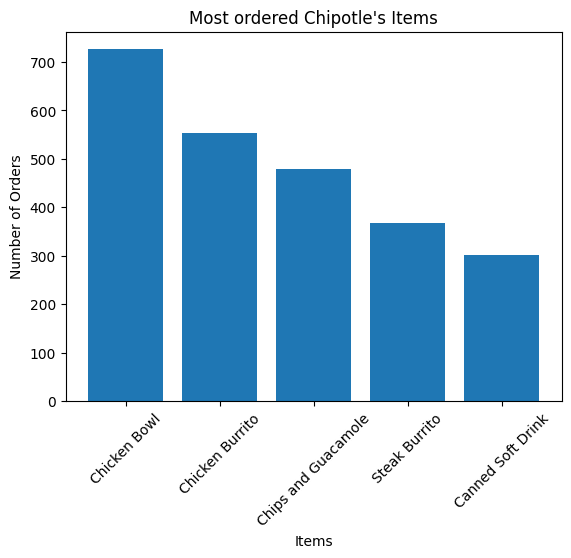

In [7]:
#상위 5개만 뽑기
top5=chipo.item_name.value_counts().head(5)

plt.bar(top5.index, top5.values)
plt.xlabel('Items')
plt.ylabel('Number of Orders')
plt.title("Most ordered Chipotle's Items")
plt.xticks(rotation=45)
plt.show()

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

In [8]:
chipo.item_price.head()

,item_price
0,$2.39
1,$3.39
2,$3.39
3,$2.39
4,$16.98


In [9]:
chipo.dtypes

,0
order_id,int64
quantity,int64
item_name,object
choice_description,object
item_price,object


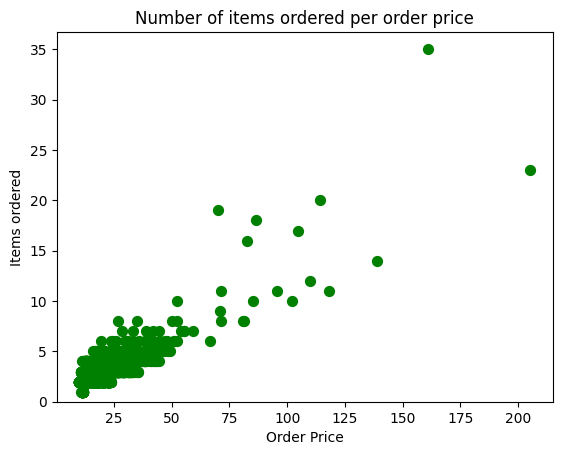

In [10]:
#숫자로 바꾸기
item_price_float = lambda x: float(x[1:-1])
chipo.item_price = chipo.item_price.apply(item_price_float)

#주문 단위로 묶어서 합계
orders = chipo.groupby('order_id').sum(numeric_only=True)


plt.scatter(x=orders.item_price, y=orders.quantity, s=50, c='green')
plt.xlabel('Order Price')
plt.ylabel('Items ordered')
plt.title('Number of items ordered per order price')
plt.ylim(0)
plt.show()

### Step 7. BONUS: Create a question and a graph to answer your own question.

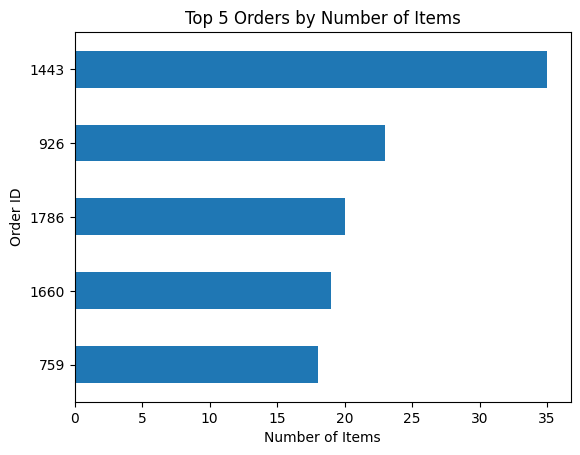

In [11]:
#아이템을 가장 많이 시킨 주문(order) top 5
orders.sort_values('quantity', ascending=False).head(5)
top5_orders = orders.sort_values('quantity', ascending=False).head(5).quantity

top5_orders.plot(kind='barh')
plt.xlabel('Number of Items')
plt.ylabel('Order ID')
plt.title('Top 5 Orders by Number of Items')
plt.gca().invert_yaxis()
plt.show()